# Análise das Relações Leitor-Livro: Características e Padrões de Consumo


Grupo:

Artur Rodrigues

Davi Cavalcante

Geraldo Neto

João Victor




##_________________________________________________________________________________________________________________________________________________________________


#**Introdução:**

### Motivação
A democratização da leitura e o acesso à literatura são temas fundamentais na sociedade contemporânea. No entanto, o consumo literário não é moldado apenas pelo interesse pessoal, mas por uma complexa teia de fatores de acessibilidade (física, digital, financeira e cultural). A motivação deste projeto nasceu da necessidade de entender como essas barreiras ou facilidades influenciam o comportamento real do leitor brasileiro.

### Objetivos da Análise
Este projeto aplica uma abordagem interdisciplinar obtida na disciplina de Introdução a Ciência de Dados para realizar uma análise das relações entre **leitores e livros**.
Planejamos entender a relação entre entre eles aplicada ao molde de um corpo/indivíduo e o espaço que a obra está inserida.

Nossos principais objetivos são:
- Mapear os padrões de engajamento (o que faz um livro ser muito lido, favoritado ou abandonado).
- Quantificar a acessibilidade financeira, comparando o impacto do custo de edições físicas (novas) versus edições digitais (e-books) na popularidade das obras.
- Identificar correlações ocultas, como a relação entre o volume da obra (quantidade de páginas) e a taxa de abandono, ou como o ano de publicação e a editora afetam a nota média perante a comunidade.

# **Dados Usados**

### Descrição do Dataset
O dataset construído reúne informações de, praticamente, 15.300 livros extraídos de plataformas digitais de leitura e comércio. Cada linha do arquivo CSV contém uma obra literária, cruzando suas métricas de engajamento social com seu valor no mercado.

Contando com registros coletados iterativamente, o dataset apresenta métricas de funil de cada obra, sendo elas: variáveis de categoria (Título, Autor, Editora), variáveis numéricas discretas (contagens de usuários que leram, abandonaram, etc.) e variáveis numéricas contínuas (Nota Média e Preços).

Observou-se inicialmente a presença de ruídos nos textos, como subtítulos de edições especiais, texto em variáveis que seriam tratadas como númericas e formatos que exigiram tratamento em etapas posteriores.

#### Dicionário do CSV
| Nome da Coluna | Descrição | Exemplo |
| :--- | :--- | :--- |
| **Título do Livro** | Nome completo do livro | Alchemised [Edição brasileira]|
| **Autor** | Nome do autor (ou autores) da obra | SenLinYu |
| **Ano** | Ano de publicação da edição correspondente | 2024 |
| **Editora** | Editora responsável pela publicação| Intrínseca |
| **Quantidade de Páginas**| Número de páginas informado na edição | 900 páginas|
| **Tempo de Leitura** | Estimativa média de tempo para ler o livro | 1d 6h 0m |
| **Nota Média** | Avaliação da comunidade (escala de 0 a 5) | 4.5 |
| **Preço Digital (R\$)** | Preço oficial do e-book na Google Play Livros | 39.90 |
| **Preço Físico (R\$)** | Média de preço de exemplares físicos novos | 65.50 |
| **Leram** | Número de usuários que marcaram "li" | 9155 |
| **Lendo** | Número de usuários que marcaram "estou lendo" | 4786 |
| **Querem** | Número de usuários que marcaram "quero ler" | 46897 |
| **Relendo** | Número de usuários que marcaram "relendo" | 43 |
| **Abandonos** | Número de usuários que registraram abandono.| 590 |
| **Resenhas** | Volume de críticas literárias publicadas | 2364 |
| **Favoritos** | Quantidade de inclusões como "livro favorito" | 1640 |
| **Avaliaram** | Número total de avaliações recebidas | 6826 |

### Exploração Inicial dos Dados

As fontes de dados foram:
- **Skoob:** Rede social para leitores do Brasil, utilizada para extrair o "comportamento social" em torno de uma obra (avaliações, abandonos, resenhas, status de leitura e metadados estruturais como páginas, ano e editora).
- **Google Books API & Estante Virtual:** Utilizadas para mapear a acessibilidade econômica das obras através da obtenção, respectivamente, do preço do e-book e o valor de mercado de exemplares físicos novos no Brasil.

A exploração inicial dos dados seguiram um pipeline em Python (Jupyter Notebook), utilizando bibliotecas como `requests`, `BeautifulSoup` e `pandas` para realização do Web Scrapping que permitiu:

- **Coleta de Link:** Utilizou-se requisições via `POST`  decodificando o formato interno do Next.js da API do Skoob para obter as URLs de cada uma das obras.
- **Extração de Métricas:** Requisições `GET` autenticadas por cookies de sessão varreram o HTML do Skoob, extraindo as métricas de cada obra por meio de classes CSS e IDs específicos.
- **Busca de Preços:** Foi desenvolvido um sistema de busca que, além de consumir a API do Google Cloud para buscar o preço da versão digital da obra, realiza o scraping da Estante Virtual para obter o preço da versão física, garantindo dados sobre diferentes formatos de consumo.
- **Filtro de Anomalias Financeiras:** Durante a coleta da Estante Virtual, o algoritmo foi programado para calcular a média de valores que um mesmo livro poderia apresentar na plataforma, rejeitando assim que estratégias de venda (como promoções, coleções, etc) distorcessem a média de preço de um livro individual. Além disso, filtrou-se explicitamente por `condition=novo` para não misturar preços de livros originais com os de sebos.




#Pré-processamento: limpeza e transformação dos dados:


Import das Bibliotecas e do CSV obtido com o Web Scrap das plataformas digitais

In [92]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.stats import zscore
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [43]:
df = pd.read_csv("skoob_todos_livros.csv")

Conversão da coluna "Tempo de Leitura" de string em formato (11h31m) para um número inteiro

In [44]:
def conversorTempo(celula):

  num = ''
  tempo = 0


  for char in str(celula):
    if char.isdigit():
      num += char
    else:
      if char == 'd':
        tempo += int(num) * 1440
      elif char == 'h':
        tempo += int(num) * 60
      elif char == 'm':
        tempo += int(num)
      num = ''

  return tempo

df['Tempo de Leitura'] = df['Tempo de Leitura'].apply(conversorTempo)
df.rename(columns={'Tempo de Leitura': 'Tempo de Leitura (Minutos)'}, inplace=True)

Tira a palavra "páginas" de todos itens da coluna e passa para float

In [45]:
df['Quantidade de Páginas'] = df['Quantidade de Páginas'].str.replace('páginas', '')
df["Quantidade de Páginas"] = pd.to_numeric(df["Quantidade de Páginas"], errors='coerce')

Tira os hífens do final de cada item da coluna

In [46]:
df['Título do Livro'] = df['Título do Livro'].str.rstrip('-')

Passa textos (Strings) para valores compreendido pelo pandas (Float ou NaN, caso não tenha sido encontrado)

In [47]:
for col in ['Preço Digital (R$)', 'Preço Físico (R$)']:
    df[col] = pd.to_numeric(df[col].replace('Não encontrado', np.nan), errors='coerce')

Descarte de linhas vazias

In [48]:
df = df.dropna(subset="Título do Livro").reset_index(drop=True)

#________________________________________________________________________________________________________________________________________________

#Perguntas:
1) O que define a acessibilidade financeira de um livro?

2) O custo interfere na leitura?

3) A fidelização interfere nas características de um livro?

4) Quais características mais influenciam no abandono?

5) Como é a relação entre livros relidos e favoritados?

6) Quais são os livros com leitores mais engajados?

7) Como é a relação dos leitores com os autores?

8) Quais características  mais impactam a nota final de um livro?

9) Como é relação entre qualidade e feedback?

#________________________________________________________________________________________________________________________________________________

#Respostas das perguntas:

#1) O que define a acessibilidade financeira de um livro?

Iniciando as análises, busquei compreender como os livros obtidos se situavam quanto sua acessibilidade econômica através de uma Análise de Distribuição dos livros quanto seu preço.

In [49]:
df['Preço Médio Estimado'] = df['Preço Físico (R$)'].fillna(df['Preço Digital (R$)'])

In [50]:
df_clean = df.dropna(subset=['Preço Médio Estimado']).copy()

df_clean['Z_Score_Preco'] = np.abs(stats.zscore(df_clean['Preço Médio Estimado']))

df_sem_outliers = df_clean[df_clean['Z_Score_Preco'] < 3].copy()

print(f"Total de livros originais com preço: {len(df_clean)}")
print(f"Total após remoção de outliers: {len(df_sem_outliers)}")

Total de livros originais com preço: 14731
Total após remoção de outliers: 14567


Para fazer a análise, utilizei Z-Score para remover valores com Z-Score maior que 3 (ou seja, outliers).
Por garantia, quis ver se não descartei muitas cédulas e, perceptivelmente, isso não ocorreu já que menos de 200 livros foram descartados.

In [51]:
df_clean['Preço Médio Estimado'] = df['Preço Físico (R$)'].fillna(df['Preço Digital (R$)'])

Percebendo que a API do Google Books não encontrou valores digitais no caso de muitos livros (por não existir a versão digital), fiz a análise de preço considerando o "Preço Médio Estimado". Ou seja, primeiro considero o preço físico, mas caso ele não exista, considero o preço digital.

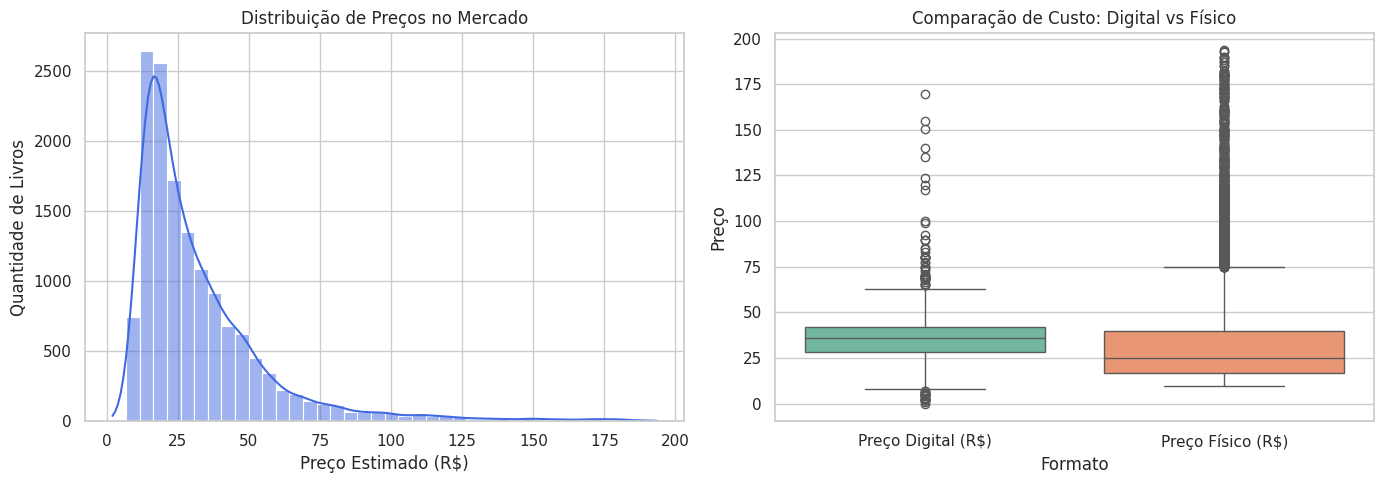

In [52]:
Pfig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_sem_outliers['Preço Médio Estimado'], bins=40, kde=True, color='royalblue', ax=ax[0])
ax[0].set_title('Distribuição de Preços no Mercado')
ax[0].set_xlabel('Preço Estimado (R$)')
ax[0].set_ylabel('Quantidade de Livros')

df_melted = df_sem_outliers.melt(value_vars=['Preço Digital (R$)', 'Preço Físico (R$)'], var_name='Formato', value_name='Preço')
sns.boxplot(data=df_melted, x='Formato', y='Preço', palette='Set2', ax=ax[1], hue='Formato', legend=False)
ax[1].set_title('Comparação de Custo: Digital vs Físico')

plt.tight_layout()
plt.show()

Com os dados tratados, busquei montar um Histograma com KDE ("Distribuição de Preços no Mercado") para mostrar a distribuição de frequências e um Boxplot ("Comparação de Custo: Digital vs Físico") para comparar distribuição entre os livros digitais e físicos.

Neste caso, o histograma demonstra que a maioria dos preços se concentra na faixa mais barata, enquanto o Boxplot demonstra como o preço digital e físico estão com uma distribuição parecida, porém com o formato físico apresentando bem mais valores extremos (muito provavelmente os livros de "edições especiais").

Por conta disso, me interessei em comparar melhor os valores de um livro no seus diferentes formatos, já que, além de uma distribuição parecida, ainda estão em uma faixa acessível, informações que, por "teorias pessoais", não esperava obter.

In [53]:
df_comparacao = df.dropna(subset=['Preço Físico (R$)', 'Preço Digital (R$)']).copy()

mediana_fisico = df_comparacao['Preço Físico (R$)'].median()
mediana_digital = df_comparacao['Preço Digital (R$)'].median()

Para essa análise, busquei analisar os preços de ambos os formatos de uma forma justa. Portanto, precisei descartar cédulas que não tivessem ambos os preços informados, além de obter o valor da mediana.

Inclusive, analisei a mediana pois o formato físico apresenta bem mais Outliers, o que, muito provavelmente, iria distorcer a comparação caso fosse feita usando uma média dos valores, que, no caso do formato físico, iria ampliar sua média de preço.


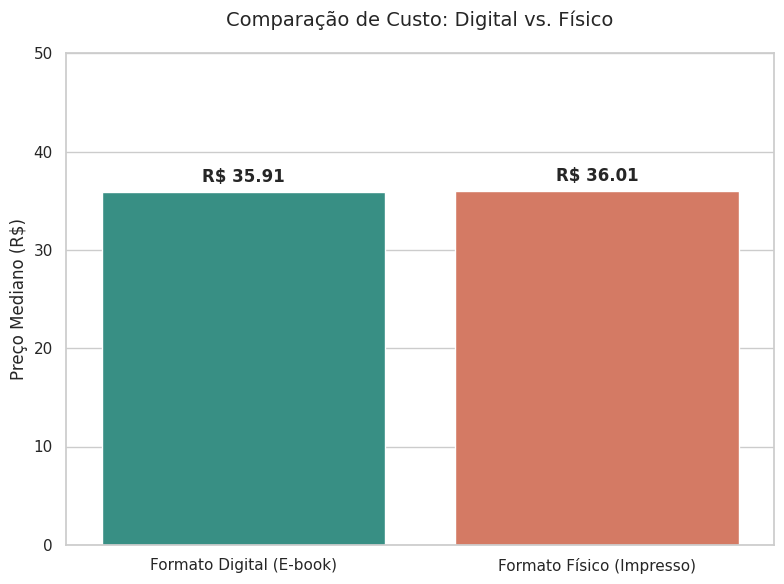

In [54]:
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x=['Formato Digital (E-book)', 'Formato Físico (Impresso)'],
    y=[mediana_digital, mediana_fisico],
    hue=['Formato Digital (E-book)', 'Formato Físico (Impresso)'],
    legend=False,
    palette=['#2a9d8f', '#e76f51']
)

plt.title('Comparação de Custo: Digital vs. Físico', fontsize=14, pad=20)
plt.ylabel('Preço Mediano (R$)', fontsize=12)

for i, v in enumerate([mediana_digital, mediana_fisico]):
    ax.text(i, v + 1, f'R$ {v:.2f}', ha='center', fontweight='bold', fontsize=12)

plt.ylim(0, 50)
plt.tight_layout()
plt.show()

Assim sendo, é perceptível como o formato digital e o formato físico apresentam valores muito parecidos. O que, enriquecendo a informação que o boxplot demonstrou, vai contra ao que imaginava.

No caso (considerando os custos de transporte, material, e impressão), imaginava que o formato físico era muito mais caro que o digital. Porém, as últimas análises me demonstraram que não e, por conta disso, quis me informar sobre o que define o custo de um livro, já que, aparentemente, independente do formato, algo os encarece "igualmente".

Para isso, analisei a relação do preço e a quantidade de páginas, o que, por considerações pessoais, teria uma relação direta:

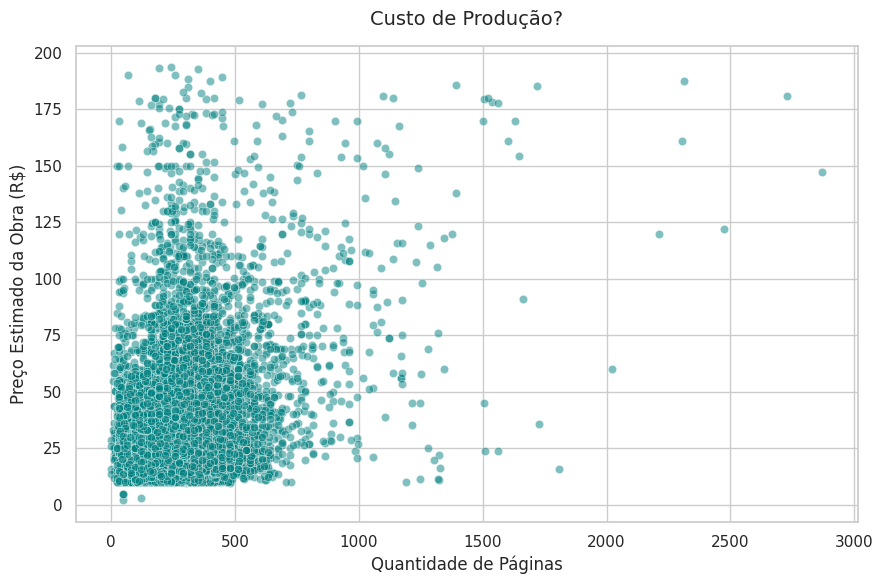

In [55]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_sem_outliers,
    x='Quantidade de Páginas',
    y='Preço Médio Estimado',
    alpha=0.5,
    color='teal'
)

plt.title('Custo de Produção?', fontsize=14, pad=15)
plt.xlabel('Quantidade de Páginas', fontsize=12)
plt.ylabel('Preço Estimado da Obra (R$)', fontsize=12)

plt.tight_layout()
plt.show()

Para a comparação entre paginas e preços, utilizei um gráfico de dispersão ("Custo de Produção") para analisar a correlação dessas variáveis.

No caso, o gráfico me demonstrou visivelmente como a quantidade de páginas e o preço se relacionam diretamente. Por conta disso, decidi fazer um gráfico de Regressão Linear e descobrir o exato acréscimo de custo que cada página causa.

Custo base inicial estimado: R$ 20.16
Acréscimo por página impressa/formatada: R$ 0.0433


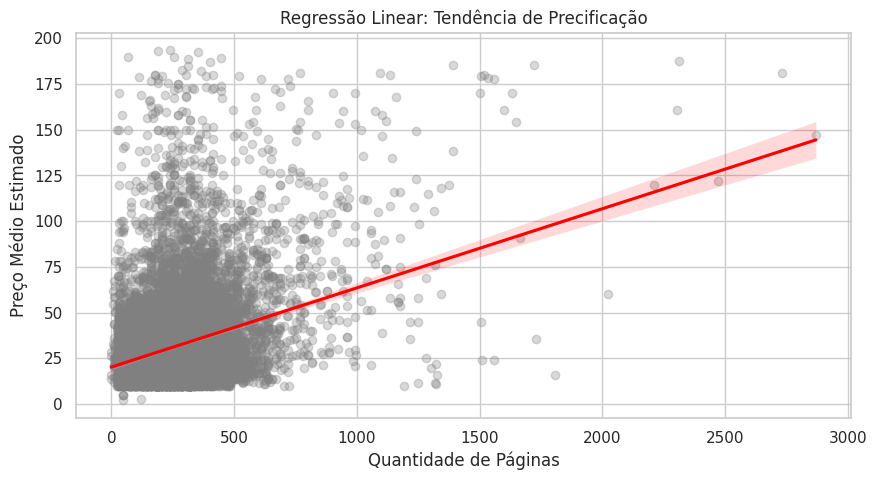

In [56]:
df_reg = df_sem_outliers.dropna(subset=['Quantidade de Páginas', 'Preço Médio Estimado'])

X = df_reg[['Quantidade de Páginas']]
y = df_reg['Preço Médio Estimado']

modelo = LinearRegression()
modelo.fit(X, y)

print(f"Custo base inicial estimado: R$ {modelo.intercept_:.2f}")
print(f"Acréscimo por página impressa/formatada: R$ {modelo.coef_[0]:.4f}")

plt.figure(figsize=(10, 5))
sns.regplot(data=df_reg, x='Quantidade de Páginas', y='Preço Médio Estimado',
            scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'red'})
plt.title('Regressão Linear: Tendência de Precificação')
plt.show()

Desse modo, é perceptível como a quantidade de páginas tem relação direta com o custo. Inclusive, cada página tem o custo de R$0.0433.

Assim sendo, é conclusivo que o preço dos livros físicos realmente dependem do custo do material para fazê-los. Porém, os livros digitais, que não têm esse custo de material, também é influenciado. Ou seja, **o custo que um livro físico tem para ser feito também é posto sobre o livro digital**.

#2) O custo interfere na leitura?

Com a resposta da pergunta anterior, também me interessei por concluir se o preço interfere na quantidade de leitores, já que, assim como "quantidade de páginas interfere no custo" e "livro físico mais caro que digital", era uma teoria pessoal minha que livros mais caros (consequentemente, como descoberto, livros com mais páginas) apresentariam menos leitores por serem menos acessíveis.

Para tal análise, busquei fazer um gráfico de barrar para comparar o tamanho do livro com a quantidade de leitores ("Retenção Real"), além do mais, já foi descoberto que quanto maior um livro, maior seu preço.
Inclusive, ainda preferi montar um gráfico de barras comparando o tamanho do livro e seu preço ("Custo de Produção") para analisar melhor a relação das três variáveis (Leitores, Preço, Quantidade de Páginas) que considerava de alguma forma proporcionais.

Destaco que analisei a mediana pelo medo de livros famosos ou Best-Sellers distorcerem as comparações. Assim sendo, busquei analisar o comportamento de um "livro comum" naquela faixa analisada.

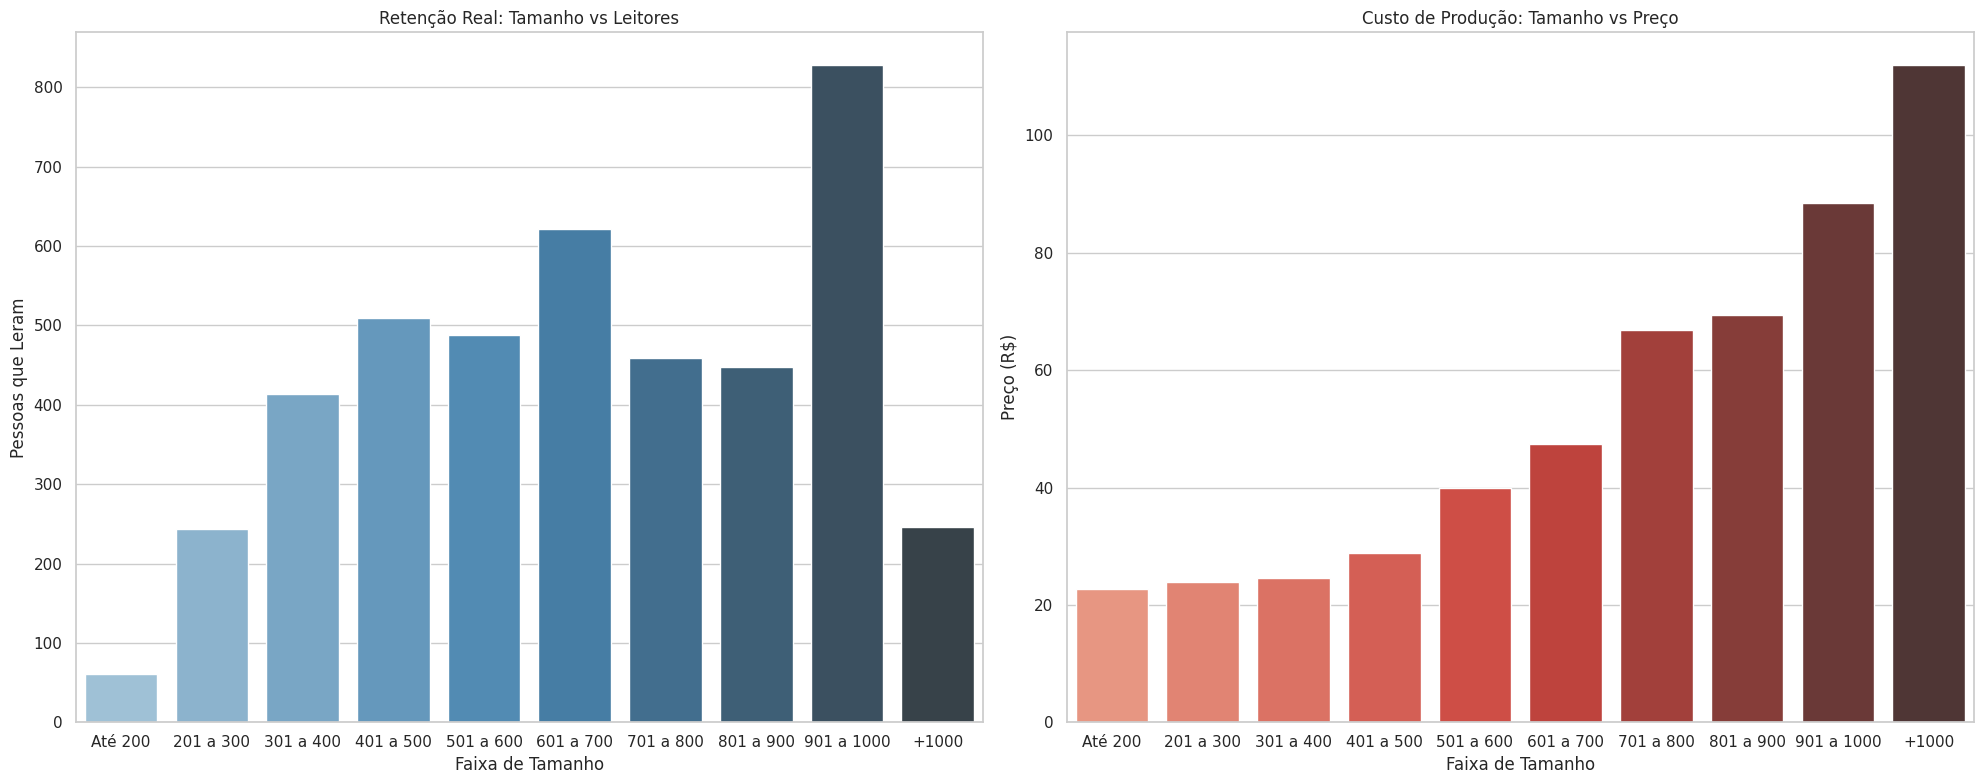

In [57]:
df_triade = df.dropna(subset=['Quantidade de Páginas', 'Leram', 'Preço Médio Estimado']).copy()

bins_pag = [0, 200, 300, 400, 500, 600, 700, 800, 900, 1000, float('inf')]
labels_pag = ['Até 200', '201 a 300', '301 a 400', '401 a 500', '501 a 600',
              '601 a 700',  '701 a 800', '801 a 900',  '901 a 1000', '+1000']
df_triade['Faixa de Tamanho'] = pd.cut(df_triade['Quantidade de Páginas'], bins=bins_pag, labels=labels_pag)

fig, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(data=df_triade, x='Faixa de Tamanho', y='Leram', hue='Faixa de Tamanho', legend=False, estimator=np.median, errorbar=None, palette='Blues_d', ax=ax[0])
ax[0].set_title('Retenção Real: Tamanho vs Leitores', fontsize=12)
ax[0].set_ylabel('Pessoas que Leram')

sns.barplot(data=df_triade, x='Faixa de Tamanho', y='Preço Médio Estimado', hue='Faixa de Tamanho', legend=False, estimator=np.median, errorbar=None, palette='Reds_d', ax=ax[1])
ax[1].set_title('Custo de Produção: Tamanho vs Preço', fontsize=12)
ax[1].set_ylabel('Preço (R$)')

plt.tight_layout()
plt.show()

Vendo como o gráfico de "Custo de Produção" se comporta de forma crescente, enquanto o gráfico de "Retenção Real" apresenta variações, decidi analisar ainda melhor unindo as três variáveis em um único gráfico agrupado.

Para tal, mantive o gráfico de barras da quantidade de leitores em diferentes tamanho de livros e sobrepus esse gráfico por uma linha que demonstra a variação do preço nesses tamanhos de livro.

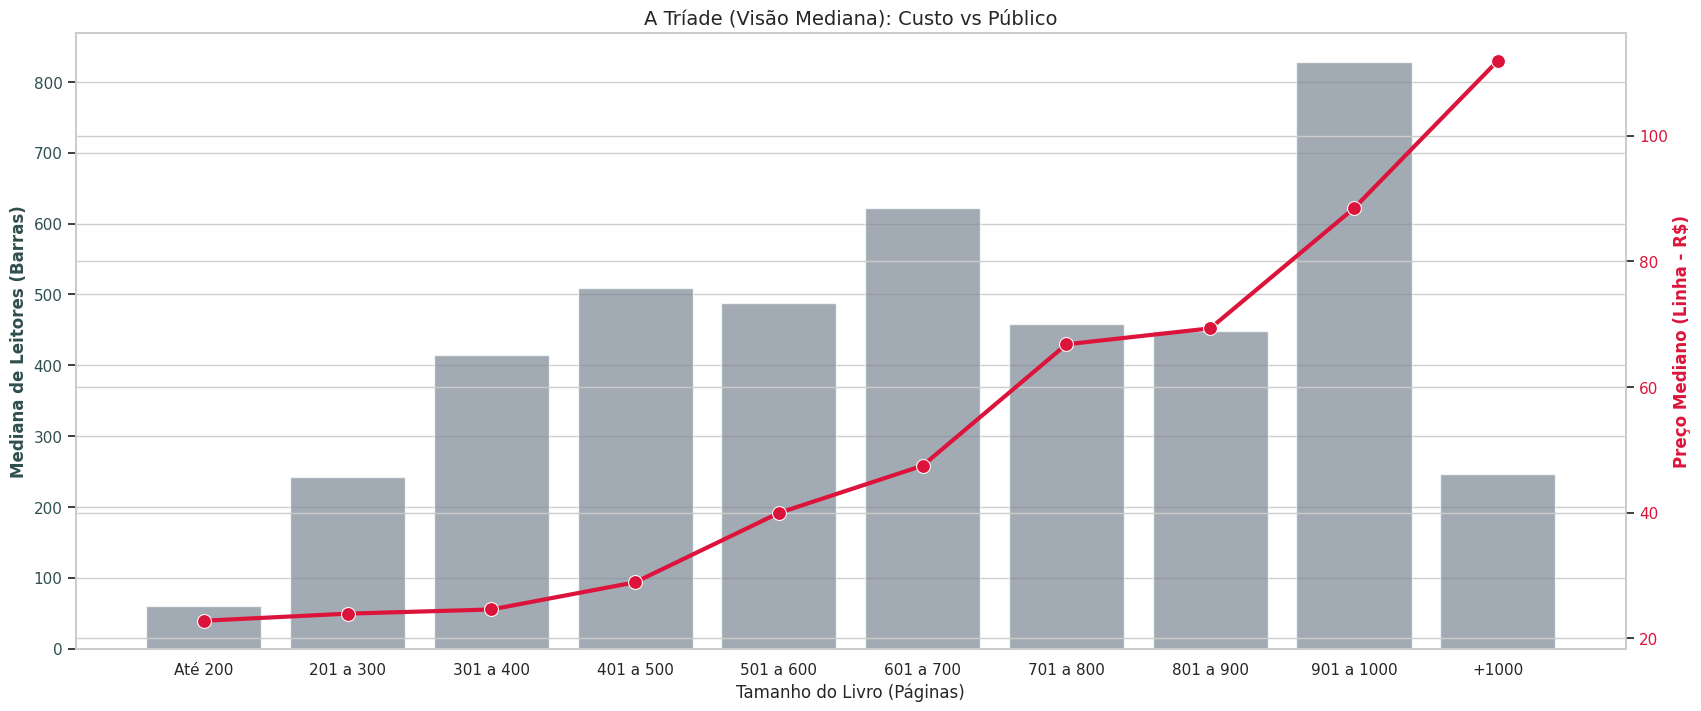

In [58]:
df_agrupado = df_triade.groupby('Faixa de Tamanho', observed=False).agg(
    Mediana_Leitores=('Leram', 'median'),
    Mediana_Preco=('Preço Médio Estimado', 'median')
).reset_index()

fig, ax1 = plt.subplots(figsize=(20, 8))

sns.barplot(data=df_agrupado, x='Faixa de Tamanho', y='Mediana_Leitores', color='lightslategray', alpha=0.7, ax=ax1)
ax1.set_ylabel('Mediana de Leitores (Barras)', color='darkslategray', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='darkslategray')
ax1.set_xlabel('Tamanho do Livro (Páginas)', fontsize=12)

ax2 = ax1.twinx()
sns.lineplot(data=df_agrupado, x='Faixa de Tamanho', y='Mediana_Preco', color='crimson', marker='o', linewidth=3, markersize=10, ax=ax2)
ax2.set_ylabel('Preço Mediano (Linha - R$)', color='crimson', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.title('A Tríade (Visão Mediana): Custo vs Público', fontsize=14)
plt.show()

Assim, é perceptível que a quantidade de leitores e o preço tem uma constante subida até a faixa de livro de 700 páginas, entretanto, enquanto o preço continua subindo, a quantidade de leitores varia.

Essa situação me surpreendeu, pois esperava o crescimento conjunto e a queda em determinada faixa, já que livros mais caros e com mais páginas, normalmente, são de maior qualidade (e, consequentemente, com mais leitores), porém haveria uma queda quando chegasse em determinada faixa pois o preço e o tamanho do livro já não "compensaria" a qualidade e poucos leitores teriam a capacidade de gastar tanto em um obra literária. Só que, diferente do que imaginava, após  a queda volta a ter uma subida nos livros de mais de 900 páginas, que também são muito mais caros.

Sendo assim, estava parcialmente correto. Além do mais, **o custo e a quantidade de páginas interfere na leitura** (é perceptível a queda na faixa de 800 páginas e custo acima de R$60), porém a surpreendente subida, me relebrou de que esqueci os Best-Sellers e seus fãs. Mesmo com o uso da mediana, os livros com maior quantidade de página e maior preço ainda são livros de alta popularidade e, consequentemente, conseguem vencer a barreira do preço e do tamanho para os leitores, que, por serem fãs, ainda conseguem acompanhar as obras.

Por conta disso, me interessei por analisar como a fidelidade estaria afetando as métricas dos livros.

#3) A fidelização interfere nas características de um livro?

Imaginando a possível influência dos fãs e Best-Sellers, busquei encontrar formas de comprovar como eles estavam afetando as métricas dos livros.

Para isso, busquei mostrar que livros com a maior quantidade de páginas realmente eram Best-Sellers considerando seus índices de favoritos, notas, relidos  e resenhas (normalmente métricas que quanto maiores, melhor uma obra é considerada).

Assim como feito em outros gráficos de barras, utilizei mediana (para evitar distorções por conta de outliers) e mensurei "Taxas" (proporção de uma métrica pela quantidade de leitores) para uma análise mais justa.

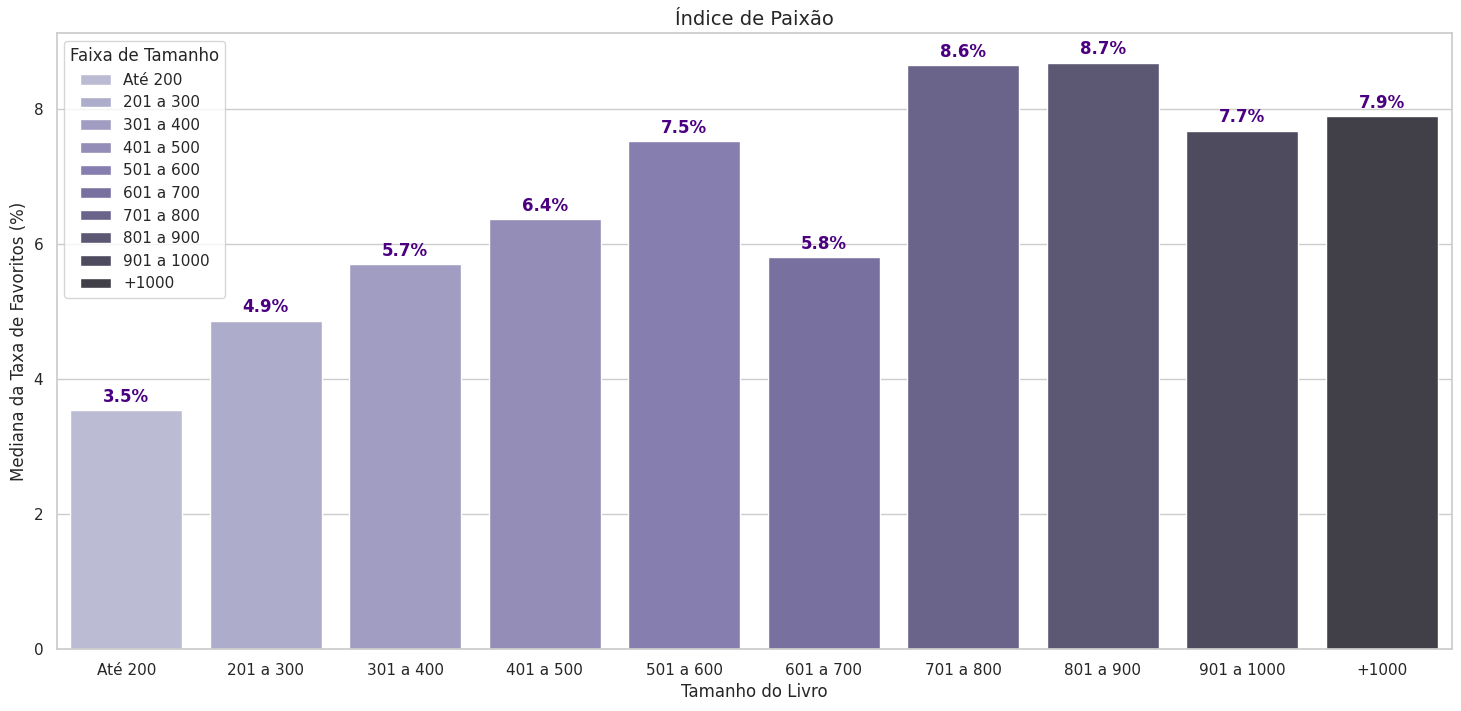

In [59]:
df_paixao = df.dropna(subset=['Favoritos', 'Leram', 'Quantidade de Páginas']).copy()
df_paixao = df_paixao[df_paixao['Leram'] > 0]

df_paixao['Taxa de Favoritos (%)'] = (df_paixao['Favoritos'] / df_paixao['Leram']) * 100

bins_pag = [0, 200, 300, 400, 500, 600, 700, 800, 900, 1000, float('inf')]
labels_pag = ['Até 200', '201 a 300', '301 a 400', '401 a 500', '501 a 600',
              '601 a 700',  '701 a 800', '801 a 900',  '901 a 1000', '+1000']
df_paixao['Faixa de Tamanho'] = pd.cut(df_paixao['Quantidade de Páginas'], bins=bins_pag, labels=labels_pag)

plt.figure(figsize=(18, 8))
ax = sns.barplot(
    data=df_paixao,
    x='Faixa de Tamanho',
    y='Taxa de Favoritos (%)',
    hue='Faixa de Tamanho',
    estimator=np.median,
    palette='Purples_d',
    errorbar=None
)

plt.title('Índice de Paixão', fontsize=14)
plt.xlabel('Tamanho do Livro', fontsize=12)
plt.ylabel('Mediana da Taxa de Favoritos (%)', fontsize=12)

for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%', padding=3, color='indigo', fontweight='bold')

plt.show()

Desse modo, comecei relacionando a quantidade de páginas com o índice "Taxa de Favoritos" e é perceptível pelo gráfico "índice de Paixão" que a taxa de favoritos aumenta conforme o tamanho do livro também aumenta.

Assim sendo, mais uma possível prova que livros maiores são best-sellers com mais fãs.

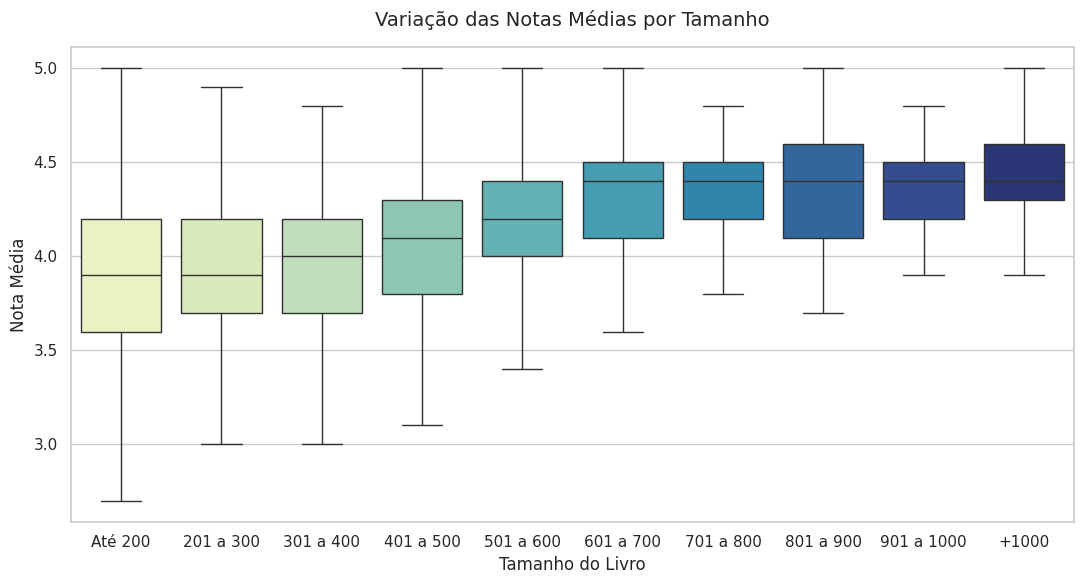

In [60]:
df_notas = df.dropna(subset=['Nota Média', 'Quantidade de Páginas']).copy()
df_notas = df_notas[df_notas['Nota Média'] > 0]
df_notas = df_notas[df_notas['Nota Média'] <= 5]

bins_pag = [0, 200, 300, 400, 500, 600, 700, 800, 900, 1000, float('inf')]
labels_pag = ['Até 200', '201 a 300', '301 a 400', '401 a 500', '501 a 600',
              '601 a 700',  '701 a 800', '801 a 900',  '901 a 1000', '+1000']
df_notas['Faixa de Tamanho'] = pd.cut(df_notas['Quantidade de Páginas'], bins=bins_pag, labels=labels_pag)

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=df_notas,
    x='Faixa de Tamanho',
    y='Nota Média',
    palette='YlGnBu',
    showfliers=False,
    hue='Faixa de Tamanho',
    legend=False
)

plt.title('Variação das Notas Médias por Tamanho', fontsize=14, pad=15)
plt.xlabel('Tamanho do Livro', fontsize=12)
plt.ylabel('Nota Média', fontsize=12)

plt.tight_layout()
plt.show()

Dessa vez relacionei a quantidade de páginas com a nota média comparando boxplots de diferentes tamanhos de livros.

Destaco que busquei evitar livros sem notas (Nota Média = 0) ou com notas erradas (Nota Média > 5).

De qualquer forma, assim como a outra comparação, é perceptível que a nota média aumenta conforme o tamanho do livro também aumenta.

Assim sendo, mais uma possível prova que livros maiores são best-sellers com mais fãs.

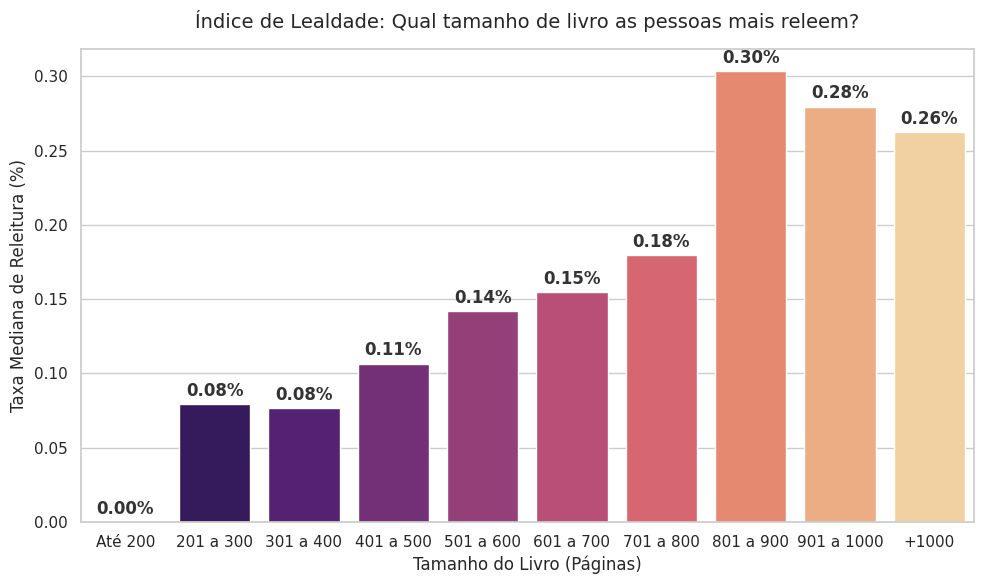

In [61]:
df_releitura = df.dropna(subset=['Leram', 'Relendo', 'Quantidade de Páginas']).copy()
df_releitura = df_releitura[df_releitura['Leram'] > 0]

df_releitura['Taxa de Releitura (%)'] = (df_releitura['Relendo'] / df_releitura['Leram']) * 100

bins_pag = [0, 200, 300, 400, 500, 600, 700, 800, 900, 1000, float('inf')]
labels_pag = ['Até 200', '201 a 300', '301 a 400', '401 a 500', '501 a 600',
              '601 a 700',  '701 a 800', '801 a 900',  '901 a 1000', '+1000']
df_releitura['Faixa de Tamanho'] = pd.cut(df_releitura['Quantidade de Páginas'], bins=bins_pag, labels=labels_pag)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_releitura,
    x='Faixa de Tamanho',
    y='Taxa de Releitura (%)',
    estimator=np.median,
    palette='magma',
    errorbar=None,
    hue='Faixa de Tamanho',
    legend=None
)

plt.title('Índice de Lealdade: Qual tamanho de livro as pessoas mais releem?', fontsize=14, pad=15)
plt.xlabel('Tamanho do Livro (Páginas)', fontsize=12)
plt.ylabel('Taxa Mediana de Releitura (%)', fontsize=12)

for i in ax.containers:
    ax.bar_label(i, fmt='%.2f%%', padding=3, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

Dessa vez relacionei a quantidade de páginas com a taxa de releitura através de um gráfico de barras.

Assim como as outras comparações, a taxa de releitura também aumenta conforme o tamanho do livro, demonstrando a "fidelidade" des leitores.
Inclusive, ainda ocorre dos livros de até 200 páginas nem sequer ter releitura, mostrando que, provavelmente, esse livros menores são livros de rápida leitura e considerados "descartáveis" por quem leu.

Assim sendo, mais uma possível prova que livros maiores são best-sellers com mais fãs.

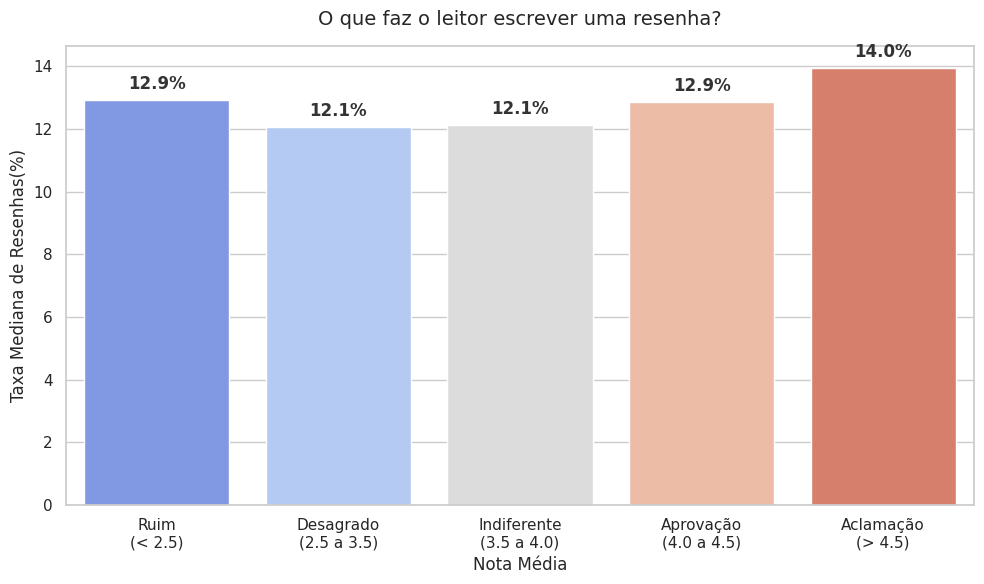

In [62]:
df_engajamento = df.dropna(subset=['Avaliaram', 'Resenhas', 'Nota Média']).copy()
df_engajamento = df_engajamento[df_engajamento['Avaliaram'] > 20]
df_engajamento['Taxa de Discussão (%)'] = (df_engajamento['Resenhas'] / df_engajamento['Avaliaram']) * 100

bins_notas = [0.1, 2.5, 3.5, 4.0, 4.5, 5.0]
labels_notas = ['Ruim\n(< 2.5)', 'Desagrado\n(2.5 a 3.5)', 'Indiferente\n(3.5 a 4.0)',
                'Aprovação\n(4.0 a 4.5)', 'Aclamação\n(> 4.5)']
df_engajamento['Faixa de Nota'] = pd.cut(df_engajamento['Nota Média'], bins=bins_notas, labels=labels_notas)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_engajamento,
    x='Faixa de Nota',
    y='Taxa de Discussão (%)',
    estimator=np.median,
    palette='coolwarm',
    errorbar=None,
    hue='Faixa de Nota',
    legend=False
)

plt.title('O que faz o leitor escrever uma resenha?', fontsize=14, pad=15)
plt.xlabel('Nota Média', fontsize=12)
plt.ylabel('Taxa Mediana de Resenhas(%)', fontsize=12)

for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%', padding=5, fontweight='bold', color='#333')

plt.tight_layout()
plt.show()

Por fim, resolvi compreender a relação dos leitores e suas resenhas para ter certeza de como a fidelização afetava as métricas de uma obra. No caso, utilizei um gráfico de barras para compreender a relação da quantidade de resenhas e a nota média das obras.

Assim como as outras comparações, calculei uma taxa de resenhas e pude perceber com clareza como essa taxa é maior nas "notas extremas" (menor que 2.5 e maior do que 4.5).

Desse modo, vê-se como tanto o "ódio" por uma obra, como o "amor" por ela impulsiona o leitor a comentar sobre ela.

Não bastasse somente todos os outros gráficos e relações mostrando a presença dos fãs nas métricas, percebe-se que a fidelização também está entre os odiadores que comprova que os livros comuns/medianos gera um engajamento menor do que os livros dos extremos.

Sendo assim, **os livros maiores e mais caros são best-sellers com mais fãs que, por conta disso, alteram as métricas e comparações ao analisar custo e quantidade de leitores.**

#4) Quais características mais influenciam no abandono?


Artur:

Além das perguntas anteriores, me interessei em descobrir quais características influenciam no abandono. No caso, foquei em observar se o preço interfere no abandono, já que, assim como "quantidade de páginas interfere no custo" e "livro físico mais caro que digital", era uma teoria pessoal minha que livros mais caros teriam menos abandonos.

In [63]:
df_analise = df.dropna(subset=['Preço Médio Estimado', 'Abandonos', 'Leram']).copy()
df_analise = df_analise[df_analise['Leram'] > 0] # Evitar divisão por zero
df_analise['Taxa de Abandono (%)'] = (df_analise['Abandonos']) / (df_analise['Leram']) * 100

Para tal, garanti que não trabalharia com cédulas nulas e desenvolvi a métrica "Taxa de Abandono" que é a proporção de abandonos pela quantidade de pessoas que leu, já que livros com mais leitores, por consequência, teriam mais abandonos do que livros com menos leitores. Inclusive, para realizar a proporção sem preocupações, filtrei a comparação para somente livros com mais de zero leitores para evitar divisão por zero.

Com os dados tratados, desenvolvi um gráfico de barras para demonstrar a taxa de abandono considerando o preço do livro.

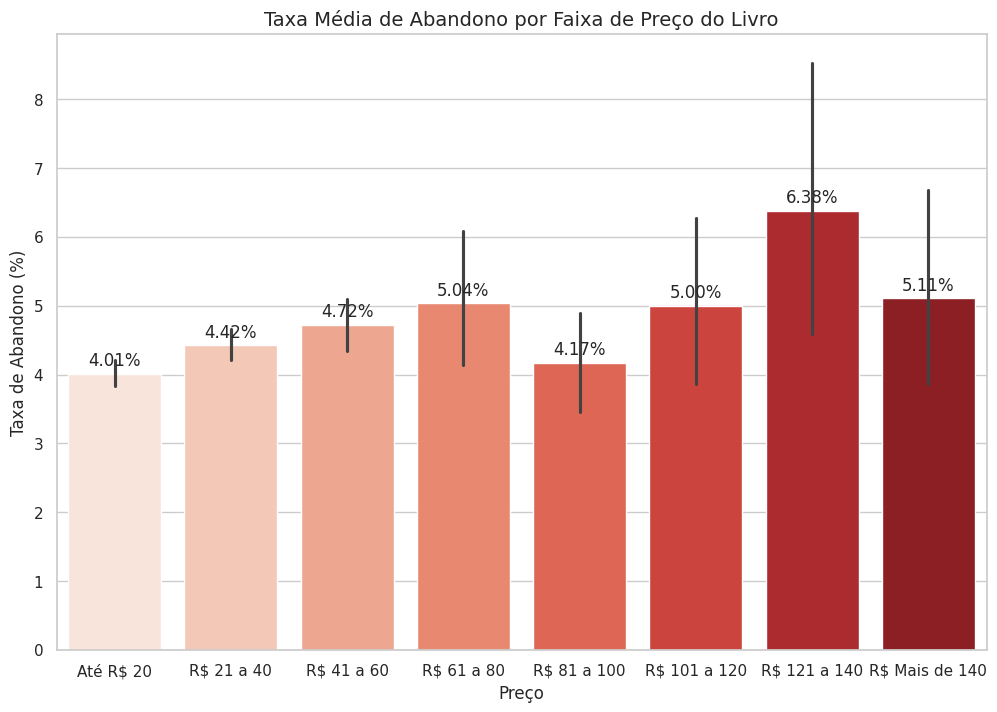

In [64]:
bins_preco = [0, 20, 40, 60, 80, 100, 120, 140, float('inf')]
labels_preco = ['Até R$ 20', 'R$ 21 a 40', 'R$ 41 a 60', 'R$ 61 a 80', 'R$ 81 a 100', 'R$ 101 a 120', 'R$ 121 a 140', 'R$ Mais de 140']
df_analise['Faixa de Preço'] = pd.cut(df_analise['Preço Médio Estimado'], bins=bins_preco, labels=labels_preco)

plt.figure(figsize=(12, 8))
ax = sns.barplot(data=df_analise, x='Faixa de Preço', y='Taxa de Abandono (%)', hue='Faixa de Preço', legend=False, estimator=np.mean, palette='Reds')

plt.title('Taxa Média de Abandono por Faixa de Preço do Livro', fontsize=14)
plt.xlabel('Preço', fontsize=12)
plt.ylabel('Taxa de Abandono (%)', fontsize=12)

for i in ax.containers:
    ax.bar_label(i, fmt='%.2f%%', padding=3)

plt.show()

É perceptível como minha teoria pessoal está errada, além do mais, a taxa de abandono é muito parecida e apresenta uma variação crescente pequena, sendo o completo oposto do que imaginava (que iria diminuir conforme o preço aumentasse).

João Vitor:

Para entender melhor que fator realmente pode fazer com que pessoas acabem por abandonar suas leituras, comecei pensando no que, pessoalmente, considerava influente para o abandono. No caso, o tamanho dos livros:


In [65]:
df = df[~df["Título do Livro"].str.contains("Box", case = False, na=False)]

coluna = 'Quantidade de Páginas'


Q1 = df[coluna].quantile(0.25)
Q3 = df[coluna].quantile(0.75)
IQR = Q3 - Q1


limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Limites aceitáveis: de {limite_inferior:.0f} até {limite_superior:.0f} páginas.")


df = df[(df[coluna] >= limite_inferior) & (df[coluna] <= limite_superior)]

Limites aceitáveis: de -45 até 587 páginas.


Foram encontrados 63 livros outliers.


/tmp/ipykernel_115172/1675613764.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_115172/1675613764.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


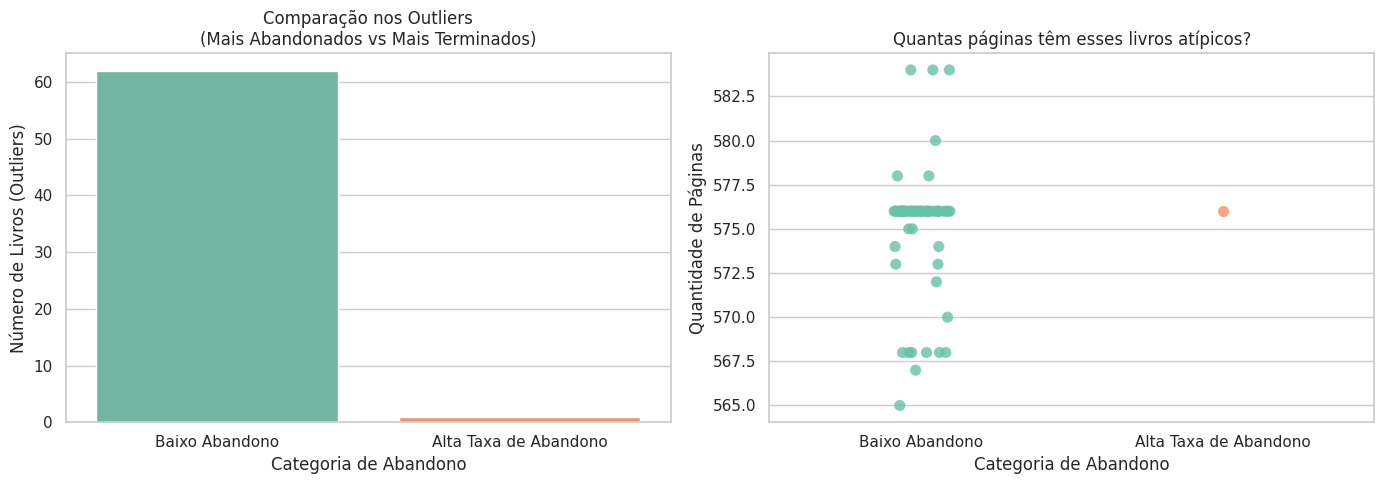

In [66]:
coluna = 'Quantidade de Páginas'

Q1 = df[coluna].quantile(0.25)
Q3 = df[coluna].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR



df_outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)].copy()

print(f"Foram encontrados {len(df_outliers)} livros outliers.")


if len(df_outliers) == 0:
    print("Seu dataset não possui outliers para essa coluna!")
else:

    threshold = 0.15

    total_tentativas = df_outliers['Leram'] + df_outliers['Abandonos']
    df_outliers['Taxa de Abandono'] = np.where(total_tentativas > 0,
                                               df_outliers['Abandonos'] / total_tentativas,
                                               0)

    df_outliers['Resultado Leitura'] = np.where(df_outliers['Taxa de Abandono'] > threshold,
                                               'Alta Taxa de Abandono',
                                               'Baixo Abandono')


    fig, axes = plt.subplots(1, 2, figsize=(14, 5))


    sns.countplot(
        x='Resultado Leitura',
        data=df_outliers,
        palette=['#66c2a5','#fc8d62'],
        ax=axes[0]
    )
    axes[0].set_title(f'Comparação nos Outliers\n(Mais Abandonados vs Mais Terminados)')
    axes[0].set_xlabel('Categoria de Abandono')
    axes[0].set_ylabel('Número de Livros (Outliers)')


    sns.stripplot(
        x='Resultado Leitura',
        y=coluna,
        data=df_outliers,
        palette=['#66c2a5','#fc8d62'],
        size=8,
        jitter=True,
        ax=axes[1],
        alpha=0.8
    )
    axes[1].set_title('Quantas páginas têm esses livros atípicos?')
    axes[1].set_xlabel('Categoria de Abandono')
    axes[1].set_ylabel('Quantidade de Páginas')

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_115172/1898092627.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


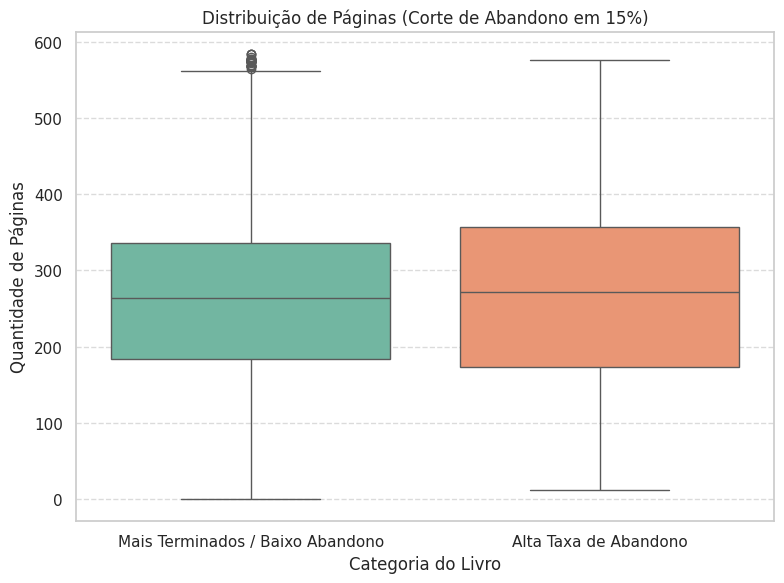

In [67]:
threshold = 0.15


total_tentativas = df['Leram'] + df['Abandonos']


df['Taxa de Abandono'] = np.where(total_tentativas > 0,
                                  df['Abandonos'] / total_tentativas,
                                  0)



df['Resultado Leitura'] = np.where(df['Taxa de Abandono'] > threshold,
                                   'Alta Taxa de Abandono',
                                   'Mais Terminados / Baixo Abandono')


plt.figure(figsize=(8, 6))

sns.boxplot(
    x='Resultado Leitura',
    y='Quantidade de Páginas',
    data=df,
    palette=['#66c2a5','#fc8d62']
)

plt.title(f'Distribuição de Páginas (Corte de Abandono em {threshold*100:.0f}%)')
plt.xlabel('Categoria do Livro')
plt.ylabel('Quantidade de Páginas')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#5) Como é a relação entre livros relidos e favoritados?

###Criação do dataframe com somente os livros que foram favoritados por 1.000 usuários ou mais.

In [68]:
df_favoritos = df[df['Favoritos'] >= 1000].copy()

###Criação de duas novas colunas com as Porcentagens de Favoritos/Lidos e Relendo/Leram de cada livro, que depois são separados em três grupos para melhor visualização, e colocados em um gráfico de dispersão.

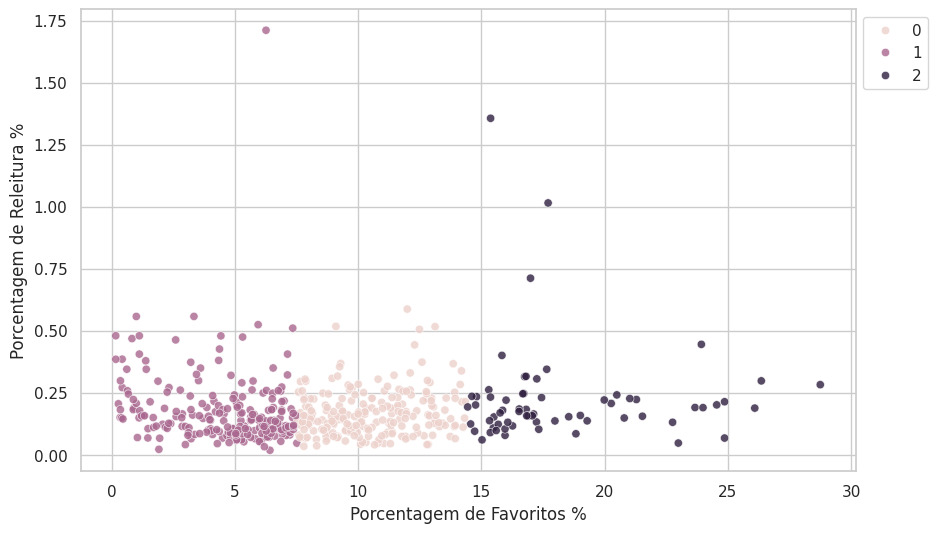

In [69]:
df_favoritos["Taxa Favoritos (%)"] = (df_favoritos['Favoritos'] / df_favoritos['Leram'])*100
df_favoritos["Taxa Relendo (%)"] = (df_favoritos['Relendo'] / df_favoritos["Leram"])*100

x_fav = df_favoritos[['Taxa Favoritos (%)', 'Taxa Relendo (%)']]

kmeans_fav = KMeans(n_clusters=3, random_state=0, n_init=10)
df_favoritos["Cluster"] = kmeans_fav.fit_predict(x_fav)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_favoritos, x='Taxa Favoritos (%)', y='Taxa Relendo (%)', hue='Cluster', alpha=0.8)
plt.xlabel('Porcentagem de Favoritos %')
plt.ylabel('Porcentagem de Releitura %')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

###Calcula a correlação entre as duas colunas.

In [71]:
df_favoritos['Taxa Favoritos (%)'].corr(df_favoritos['Taxa Relendo (%)'])

np.float64(0.0522295951295749)

###Os Top 5 livros com a maior taxa de releitura do nosso gráfico

In [73]:
livros = df_favoritos[['Título do Livro', 'Taxa Relendo (%)', 'Taxa Favoritos (%)','Quantidade de Páginas' ,'Nota Média']]

livros.sort_values("Taxa Relendo (%)", ascending = False).head(5)

,Título do Livro,Taxa Relendo (%),Taxa Favoritos (%),Quantidade de Páginas,Nota Média
6516,Mulheres que Correm com os Lobos - Mitos e his...,1.710873,6.266451,576.0,4.2
2163,A toca das raposas (Tudo Pelo Jogo #1),1.356127,15.377661,294.0,4.2
5631,O Amor Não é Obvio,1.014910,17.710069,392.0,4.5
1849,O rei corvo (Tudo Pelo Jogo #2),0.711669,16.996337,364.0,4.5
11034,O Lado Mais Sombrio (Splintered #1) - O Lado M...,0.587163,11.996356,368.0,4.1


#6) Quais são os livros com leitores mais engajados?

###Criação do dataframe com somente os livros que foram lidos por 100.000 usuários ou mais.

In [74]:
df_engajamento = df[df['Leram'] >= 100000].copy()

###Criação de duas novas colunas com as Taxas de avaliações por leitura e de resenhas por avaliação. Essas colunas são separadas em três grupos com base nessas taxas e são bastante visíveis no gráfico.

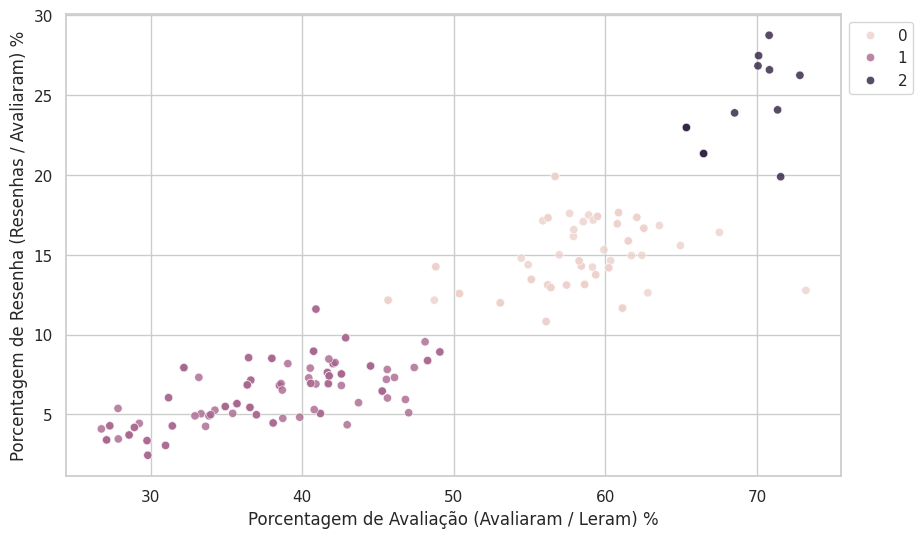

In [76]:
df_engajamento["Taxa avaliaram (%)"] = (df_engajamento['Avaliaram'] / df_engajamento['Leram'])* 100
df_engajamento["Taxa resenhas (%)"] = (df_engajamento['Resenhas'] / df_engajamento['Avaliaram'])* 100

x_eng = df_engajamento[['Taxa avaliaram (%)', 'Taxa resenhas (%)']]

scaler = StandardScaler()
x_eng_esc = scaler.fit_transform(x_eng)

kmeans_eng = KMeans(n_clusters= 3, random_state=0, n_init=10)
df_engajamento["Cluster"] = kmeans_eng.fit_predict(x_eng_esc)

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_engajamento, x='Taxa avaliaram (%)', y='Taxa resenhas (%)', hue='Cluster', alpha=0.8)
plt.xlabel('Porcentagem de Avaliação (Avaliaram / Leram) %')
plt.ylabel('Porcentagem de Resenha (Resenhas / Avaliaram) %')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

###Correlação do número de avaliações com o número de resenhas.

In [77]:
df_engajamento['Taxa avaliaram (%)'].corr(df_engajamento['Taxa resenhas (%)'])

np.float64(0.8876462105986306)

###Seleciona os livros do grupo 2 (grupo com maior engajamento) e os organiza em ordem decrescente com base na taxa de avaliação (Avaliaram/Leram).

In [78]:
livros = df_engajamento[df_engajamento['Cluster'] == 2][['Título do Livro', 'Taxa resenhas (%)', 'Taxa avaliaram (%)', 'Nota Média']]

livros.sort_values("Taxa avaliaram (%)", ascending = False).head(5)

,Título do Livro,Taxa resenhas (%),Taxa avaliaram (%),Nota Média
1799,"Amor, teoricamente",26.236711,72.830052,4.4
6457,Eu e Esse Meu Coração,19.881650,71.560737,4.2
4600,A paciente silenciosa,24.070017,71.358513,4.3
4744,Noites brancas (Coleção História de Amor),26.577249,70.822191,4.1
2045,A empregada (A Empregada #1) - Bem-vinda à fam...,28.741645,70.798903,4.3


Comentário: A maioria desses livros são de Romance.

#7) Como é a relação dos leitores com os autores?


###Criação e limpeza do dataframe dos autores

In [79]:
dflimpeza = df.assign(Autor=df['Autor'].str.split(',')).explode('Autor')
dflimpeza['Autor'] = dflimpeza['Autor'].str.strip()

lixo = ['J.K Rowling', 'J. K. Rowling', 'Emily Bronte']
dflimpeza = dflimpeza[~dflimpeza['Autor'].isin(lixo)]

df_autores = dflimpeza.groupby('Autor').agg({'Leram': 'sum', 'Lendo': 'sum' ,'Abandonos': 'sum', 'Relendo': 'sum', 'Querem': 'sum', 'Favoritos': 'sum', 'Nota Média': 'mean'}).reset_index()

###Seleciona os Top 100 autores mais lidos

In [80]:
df_autores100 = df_autores.sort_values('Leram', ascending=False).head(100)

###Gráfico de dispersão 4D, com o número de abandonos pelo número de leitores

In [81]:
grafico = px.scatter(
    df_autores100,
    x='Leram',
    y='Abandonos',
    size='Lendo',
    color='Nota Média',
    text='Autor',
    color_continuous_scale='reds',


)
grafico.update_traces(textposition='top center')
grafico.show()

###Cálculo da porcentagem de abandono (porcentagem de pessoas que tentaram ler e abandonaram) e plotagem do gŕafico de barras dos autores com maior porcentagem de abandono.

/tmp/ipykernel_115172/4115713350.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




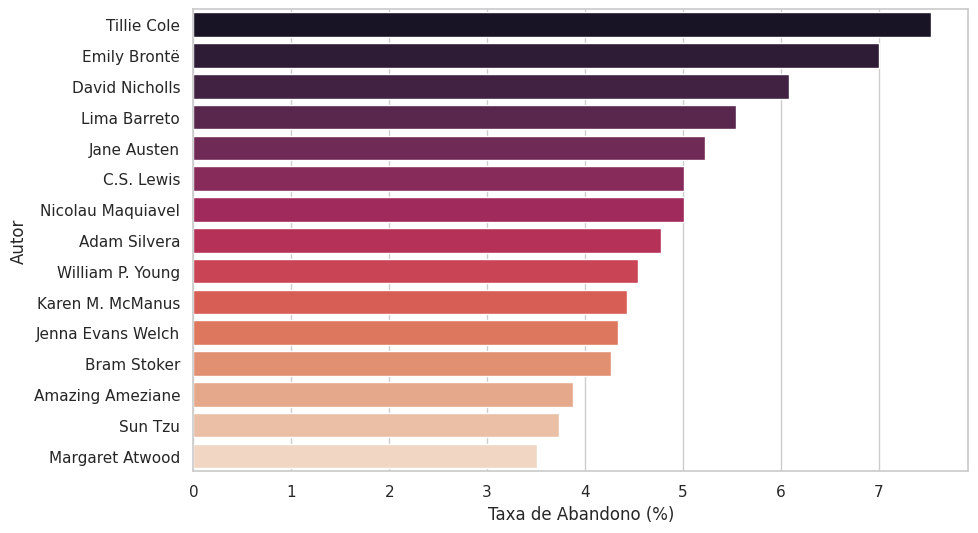

In [82]:
df_autores100['Taxa Abandono'] = (df_autores100['Abandonos'] / (df_autores100['Leram'] + df_autores100['Abandonos'])) * 100


top_abandonos = df_autores100.sort_values('Taxa Abandono', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_abandonos, x='Taxa Abandono', y='Autor', palette='rocket')
plt.xlabel('Taxa de Abandono (%)')
plt.ylabel('Autor')
plt.show()

###Gráfico 4D do número de usuários lendo pelo número de usuários que já leram, com o tamanho das bolinhas correspondendo ao número de pessoas que querem ler e a cor a nota média do autor.

In [83]:
grafico = px.scatter(
    df_autores100,
    x='Leram',
    y='Lendo',
    size='Querem',
    color='Nota Média',
    text='Autor',
    color_continuous_scale='reds',

)
grafico.update_traces(textposition='top center')
grafico.show()


###Cálculo da porcentagem de novos leitores de cada autor

/tmp/ipykernel_115172/1629090408.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




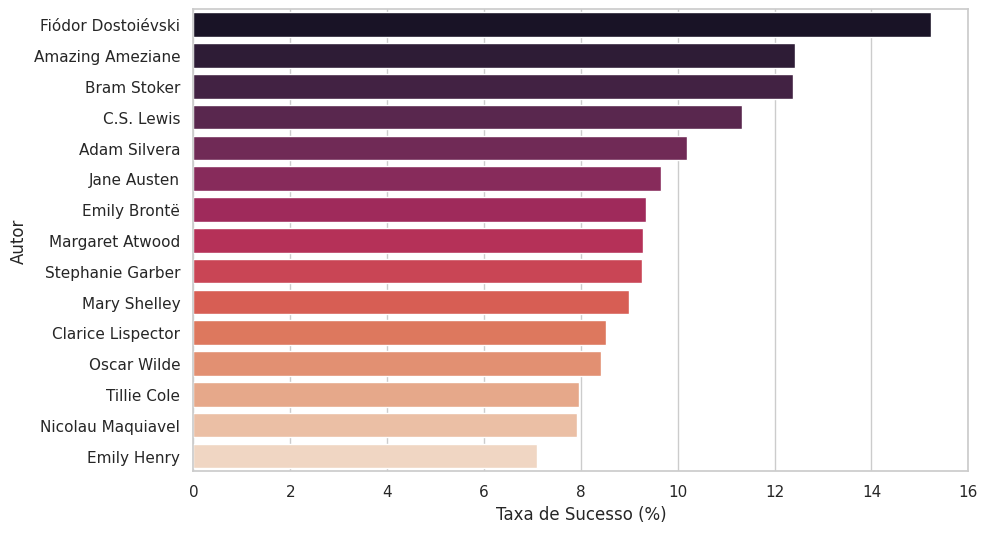

In [84]:
df_autores100['Taxa Sucesso'] = (df_autores100['Lendo'] / df_autores100['Leram']) * 100


top_abandonos = df_autores100.sort_values('Taxa Sucesso', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_abandonos, x='Taxa Sucesso', y='Autor', palette='rocket')
plt.xlabel('Taxa de Sucesso (%)')
plt.ylabel('Autor')
plt.show()

#8) o que mais influência na nota média de um livro



In [85]:
df = df.dropna(subset=['Nota Média'])

In [86]:
df['Taxa_Favoritos'] = (df['Favoritos'] / df['Avaliaram']).fillna(0)
df['Taxa_Abandono'] = (df['Abandonos'] / (df['Leram'] + df['Abandonos'])).fillna(0)
df['Taxa_Resenhas'] = (df['Resenhas'] / df['Avaliaram']).fillna(0)

Score R²: 0.16


/tmp/ipykernel_115172/3381639280.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




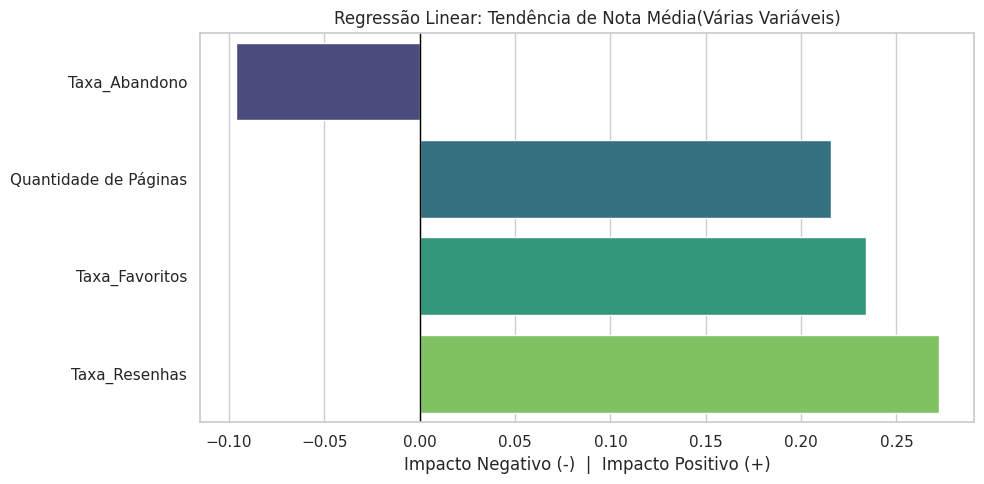

In [87]:

X = df[['Quantidade de Páginas', 'Taxa_Favoritos', 'Taxa_Abandono', 'Taxa_Resenhas']]
y = df['Nota Média']
X = X.fillna(0)

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)


scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X)


X_padronizado = pd.DataFrame(X_padronizado, columns=X.columns)


X_train, X_test, y_train, y_test = train_test_split(X_padronizado, y, test_size=0.2, random_state=42)


modelo = LinearRegression()
modelo.fit(X_train, y_train)

previsoes = modelo.predict(X_test)
print(f"Score R²: {r2_score(y_test, previsoes):.2f}")


coeficientes = pd.DataFrame({
    'Variável': X.columns,
    'Importância Real': modelo.coef_
}).sort_values(by='Importância Real', ascending=True)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importância Real', y='Variável', data=coeficientes, palette='viridis')
plt.title('Regressão Linear: Tendência de Nota Média(Várias Variáveis)')
plt.xlabel('Impacto Negativo (-)  |  Impacto Positivo (+)')
plt.ylabel('')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

# 9) Como é a relação entre qualidade e feedback?

A primeira coisa a ser feita é analisar a correlação entre quantidade de pessoas que leram e a quantidade de feeedback:

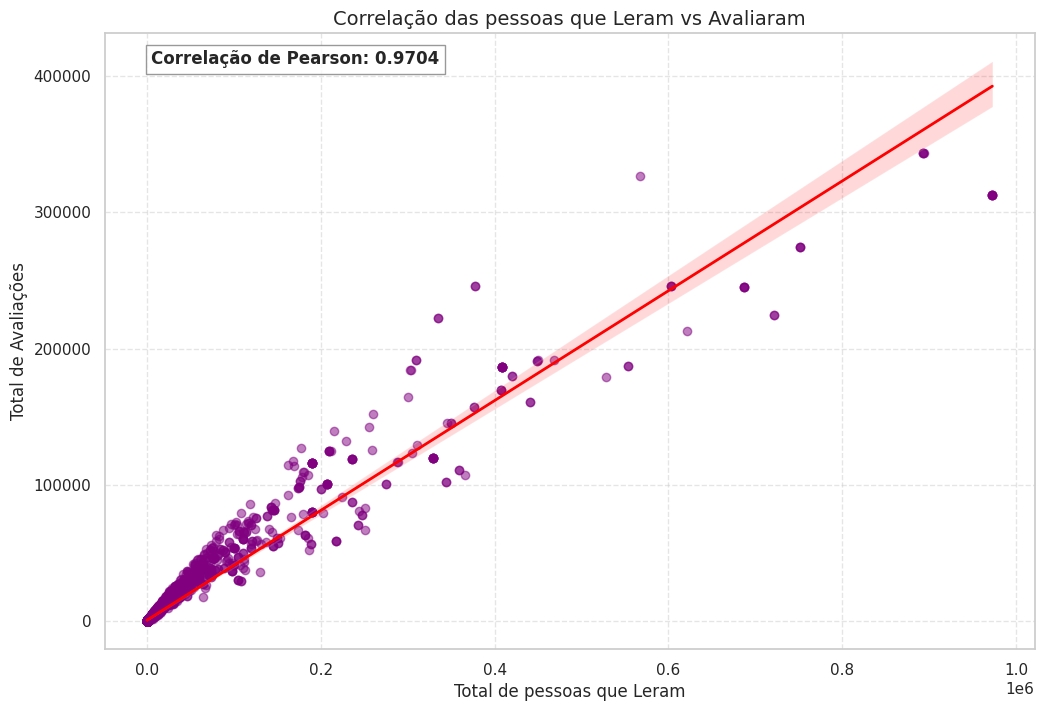

In [88]:
plt.figure(figsize=(12, 8))
ax = sns.regplot(
    data=df,
    x='Leram',
    y='Avaliaram',
    scatter_kws={'alpha':0.5, 'color':'purple'},
    line_kws={'color':'red', 'lw':2}
)

corr = df['Leram'].corr(df['Avaliaram'])

ax.text(0.05, 0.95, f'Correlação de Pearson: {corr:.4f}',
        transform=ax.transAxes, fontsize=12, fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.title('Correlação das pessoas que Leram vs Avaliaram', fontsize=14)
plt.xlabel('Total de pessoas que Leram', fontsize=12)
plt.ylabel('Total de Avaliações', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Como a correlação foi bem próxima de 1.00, vemos que as variáveis estão bem relacionadas. Dito isso, agora irei fazer vários boxplots relacionados a cada nota média arredondada (para uma maior variação), e analisar os principais valores de cada boxplot com o intuito de entender se a qualidade de um livro, seja ele bom um ruim, afeta na quantidade de feedback. Além disso, farei um boxplot da média geral para entender como os livros se situam qualitativamente no skoob.

/tmp/ipykernel_115172/2551314921.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Total de livros outliers: 2328


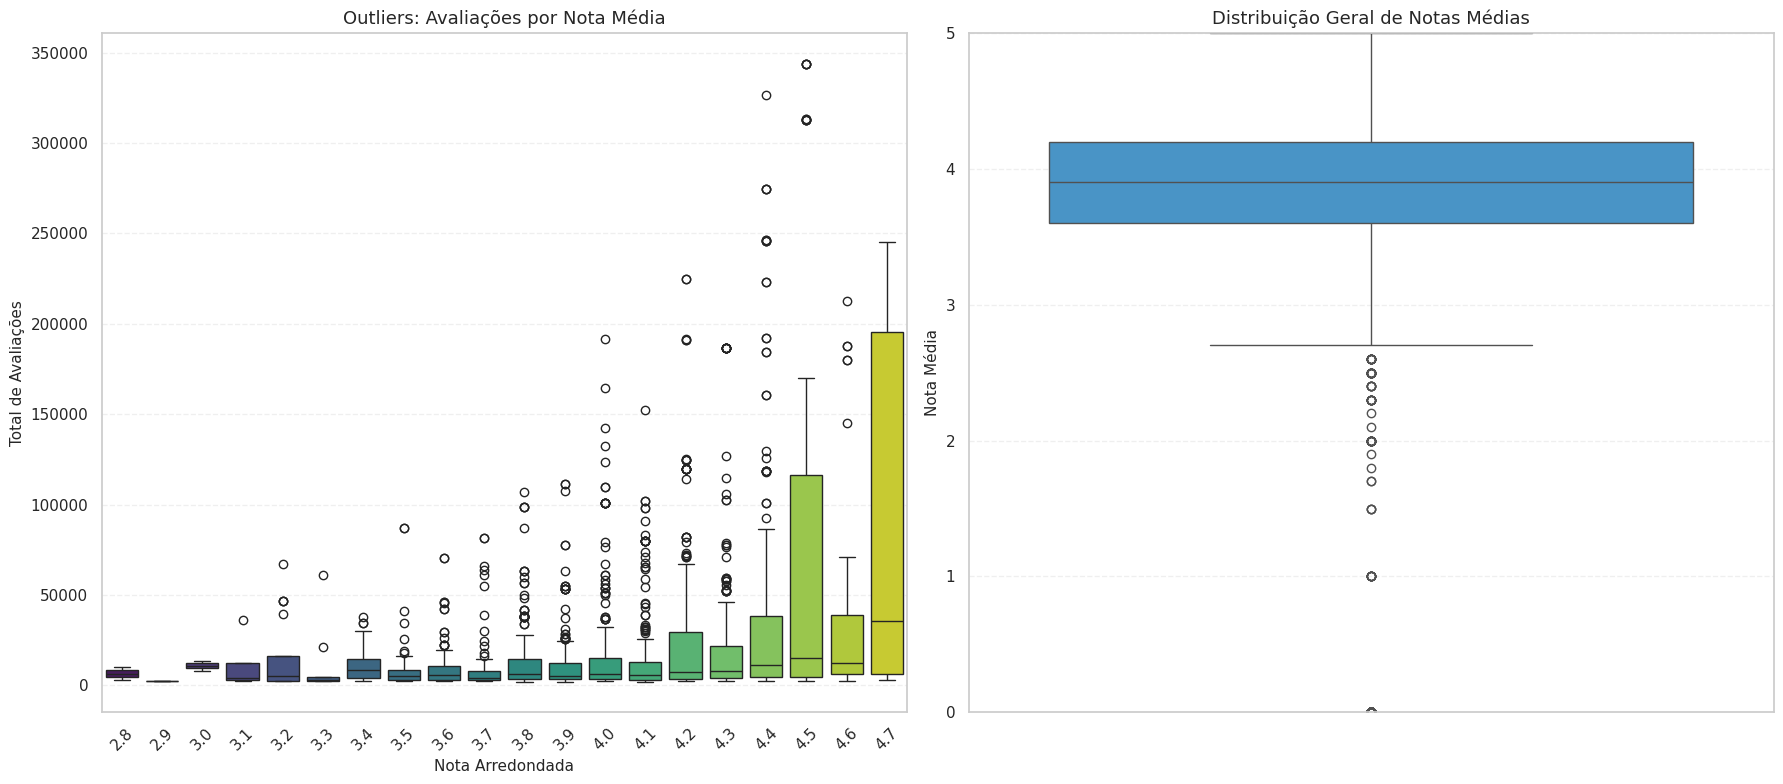

In [89]:
Q1 = df['Avaliaram'].quantile(0.25)
Q3 = df['Avaliaram'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

df_outliers = df[df['Avaliaram'] > limite_superior].copy()
df_outliers['Nota_Arredondada'] = df_outliers['Nota Média'].round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

sns.boxplot(
    data=df_outliers,
    x='Nota_Arredondada',
    y='Avaliaram',
    palette='viridis',
    ax=ax1
)
ax1.set_title('Outliers: Avaliações por Nota Média', fontsize=13)
ax1.set_xlabel('Nota Arredondada', fontsize=11)
ax1.set_ylabel('Total de Avaliações', fontsize=11)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

sns.boxplot(
    y=df['Nota Média'],
    color='#3498db',
    ax=ax2
)
ax2.set_ylim(0, 5)
ax2.set_title('Distribuição Geral de Notas Médias', fontsize=13)
ax2.set_ylabel('Nota Média', fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
print(f"Total de livros outliers: {len(df_outliers)}")
plt.show()

In [90]:
df_outliers = df[df['Avaliaram'] > (df['Avaliaram'].quantile(0.75) + 1.5 * (df['Avaliaram'].quantile(0.75) - df['Avaliaram'].quantile(0.25)))] \
    .assign(Nota_Arredondada=df['Nota Média'].round(1)) \
    .sort_values('Avaliaram', ascending=False) \
    .groupby('Nota_Arredondada').head(1)[['Nota_Arredondada', 'Título do Livro', 'Avaliaram', 'Leram']] \
    .sort_values(['Nota_Arredondada', 'Avaliaram'], ascending=[False, False])

df_outliers

,Nota_Arredondada,Título do Livro,Avaliaram,Leram
12192,4.7,Harry Potter e o Prisioneiro de Azkaban (Harry...,245071.0,686666.0
12194,4.6,Harry Potter e o Cálice De Fogo (Harry Potter ...,212786.0,621560.0
5370,4.5,Harry Potter e a Pedra Filosofal (Harry Potter...,343910.0,893380.0
7015,4.4,É assim que acaba (É Assim Que Acaba #1),326833.0,567076.0
4857,4.3,A Revolução dos Bichos,186475.0,408409.0
11801,4.2,A culpa é das estrelas [Edição econômica],225036.0,721809.0
5906,4.1,Todas as Suas (Im)Perfeições,152180.0,259979.0
11993,4.0,A Elite (A Seleção #2) - Seis garotas e uma coroa,191607.0,468497.0
12568,3.9,Amanhecer (Crepúsculo #4) - Parte I,111159.0,358825.0
7943,3.8,A Cabana,107025.0,365968.0


Bom o esperado aconteceu, o pior e o melhor livro tem alta taxa de feedback, mas por incrível que pareça o pior livro tem uma taxa muito maior, isso pode indicar que o livro é tão ruim que todos sentiram necessidade em avaliar. Outro destaque interessante a ser feito é como Harry Potter domina a tabela e também como livros de saga também se fazem bem presentes.

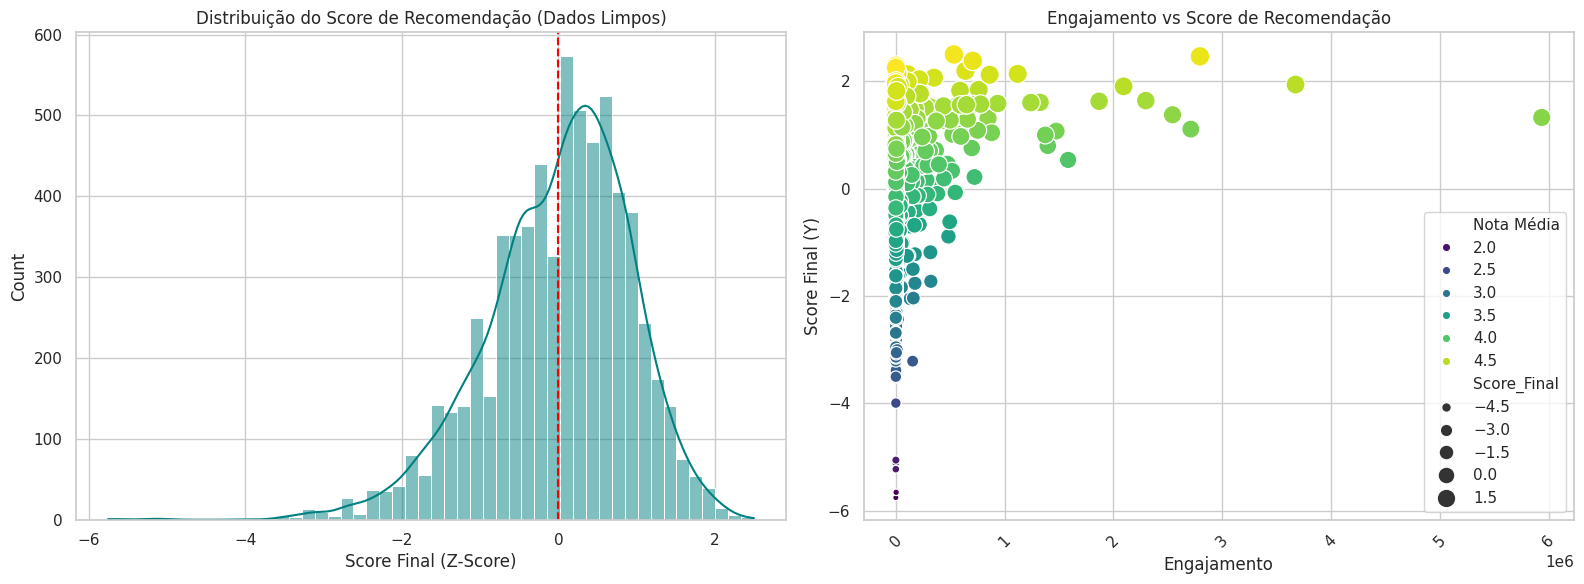


--- TOP 10 RECOMENDAÇÕES ---


,Título do Livro,Nota Média,Engajamento,Score_Final
5836,Harry Potter e as Relíquias da Morte (Harry Po...,4.750000,534136.0,2.499785
5839,Harry Potter e o Prisioneiro de Azkaban (Ediçã...,4.700000,2795861.0,2.464762
9494,O último olimpiano (Percy Jackson e os Olimpia...,4.700000,707837.0,2.381526
2315,Arrastados - Os bastidores do rompimento da ba...,4.800000,1867.0,2.292401
12382,Um Eco Na Escuridão (A Marca do Leão #2),4.800000,986.0,2.253745
1205,A odisseia de Hakim - Da Macedônia à França,4.800000,485.0,2.210817
5837,Harry Potter e o Cálice de Fogo (Harry Potter ...,4.633333,640230.0,2.195018
2646,Atlas das terras de gelo e fogo - Mapas comple...,4.800000,289.0,2.179531
3878,Crooked Kingdom - Vingança e Redenção (Six of ...,4.700000,25184.0,2.179389
9256,O rouxinol (Pop Chic) - Na França sitiada pelo...,4.700000,17340.0,2.156777


In [93]:
import re

df_valid = df[df['Nota Média'] <= 5].copy()

#regex para limpar volumes de séries e edições
def limpar_titulo_raiz(nome):
    if not isinstance(nome, str): return ""
    return re.split(r'[#\(\[\-\:]', nome)[0].lower().strip()

df_valid['Titulo_Original'] = df_valid['Título do Livro'].apply(limpar_titulo_raiz)

#Agrupar por Título e somar o Engajamento
df_clean = df_valid.groupby('Titulo_Original').agg({
    'Título do Livro': 'first',
    'Nota Média': 'mean',
    'Leram': 'sum',
    'Lendo': 'sum',
    'Avaliaram': 'sum'
}).reset_index(drop=True)

df_clean['Engajamento'] = df_clean['Leram'] + df_clean['Lendo']

#Mediana de Engajamento para evitar livros desconhecidos
df_final = df_clean[df_clean['Engajamento'] >= df_clean['Engajamento'].median()].copy()


#calculo do zscore com log


#Normaliza satisfação e popularidade real
df_final['z_nota'] = zscore(df_final['Nota Média'])
df_final['z_eng'] = zscore(np.log1p(df_final['Engajamento']))

#score de recomendação: 70% Nota e 30% Popularidade Real
df_final['Score_Final'] = (df_final['z_nota'] * 0.9) + (df_final['z_eng'] * 0.1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1 histograma
sns.histplot(df_final['Score_Final'], kde=True, color='teal', bins=50, ax=ax1)
ax1.set_title('Distribuição do Score de Recomendação (Dados Limpos)')
ax1.set_xlabel('Score Final (Z-Score)')
ax1.axvline(0, color='red', linestyle='--')

# Gráfico 2 dispersão
sns.scatterplot(data=df_final, x='Engajamento', y='Score_Final',
                hue='Nota Média', size='Score_Final', palette='viridis', sizes=(20, 200), ax=ax2)
ax2.set_title('Engajamento vs Score de Recomendação')
ax2.set_ylabel('Score Final (Y)')

# Garantir que os labels do eixo X não sobreponham
plt.sca(ax2)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


#Ranking
print("\n--- TOP 10 RECOMENDAÇÕES ---")
# Usando display() para renderizar como tabela HTML formatada no Notebook
ranking = df_final.sort_values('Score_Final', ascending=False)[['Título do Livro', 'Nota Média', 'Engajamento', 'Score_Final']].head(10)
display(ranking)

###Limitações do Estudo

1. O Viés do Relato:
Os dados do Skoob dependem inteiramente da inserção manual dos utilizadores. Podendo gerar:

    Falso Engajamento: Utilizadores podem marcar clássicos ou livros densos como "Lidos" ou dar notas altas apenas para parecerem intelectuais para os seus seguidores, mesmo sem terem terminado a obra.

    Esquecimento e Desatualização: Muitos leitores podem de esquecer de atualizar o estado de um livro.

    Métricas de Tempo Incompletas: Variáveis como "Tempo de Leitura" não são rigorosamente controladas. Muitos leem sem cronometrar ou inserem datas de início e fim aproximadas.

2. Extração Desatualizada:
O Web Scraping do mercado pegou os preços em um momento específico. O preço de um livro na Amazon ou Estante Virtual pode ter alterações.

###Trabalhos Futuros e Melhorias

1. O Fator "Gênero Literário":
Expandir a raspagem em outras plataformas para incluir outras informações de uma obra literária, como Gênero, Ano de publicação, entre outros. Assim seria possível expandir e enriquecer as análises ja feitas (Ex: Livros Fantasia do ano de 1980 são mais caros que livros de Ação de 2010) e até dá mais segurança dos dados obtidos.

2. Atualizar dados:
Conseguir realizar extrações periodicamente do Skoob e outras plataformas usadas. Isso permitiria mapear a "Curvas" dos mais diversos conceitos, como "Variação de preço", "Decadência/Melhora da popularidade", e "Período de tempo para um livro ser esquecido".

#Conclusão:
1 . O custo que um livro físico tem para ser feito também é posto sobre o livro digital.

2 . O custo e a quantidade de páginas interfere na leitura.

3 . Os livros maiores e mais caros são best-sellers com mais fãs que, por conta disso, alteram as métricas e comparações ao analisar custo e quantidade de leitores.

4 . Fica perceptivel que o tamanho do livro e o custo dele nada importa para taxa de abandono.

5 . A correlação entre a taxa de favoritismo e a taxa de releitura é muito
 próxima de zero, ou seja, pouquíssimos leitores ficam presos na zona de conforto e exploram novos livros.

6 . A correlação entre a taxa de resenhas e a taxa de avaliações é bem grande, evidenciando que quando os leitores param para avaliar um livro, tem mais chances dele deixar uma resenha também. Adição: o grupo com leitores mais engajados é composto por livros de romance.

7 . Fazendo pesquisas na internet procurei motivos para os Autores mais "Abandonados" terem esses números. Tillie Cole: Atrai bastante público por escrever romances, mas aparentemente o conteúdo de seus livros têm qualidade questionável, além de que foi cancelada na comunidade de leitores do TikTok.
Emily Brontë e Jane Austen: Ambas são escritoras de romance e seus livros tiveram adaptações de sucesso no cinema, o que deve ter atraído novos leitores, mas as duas são escritoras de época e seus livros tem uma linguagem mais antiga e de ritmo mais lento o que pode ter feito a galera desistir.

Autores hypados: Dostoiévski é destaque entre os autores mais lidos recentemente, graças ao seu sucesso na comunidade de livros do TikTok e porque seus livros são considerados "Cult".

8 . Como esperado, a taxa de abandono afeta negativamente a nota média. Porém esta regressão linear pode ser melhorada de diversas formas no futuro.

9 . Foi identificado que livros muito bons e livros muito ruins tem uma altissima taxa de feedback, evidenciando que ódio e amor são métricas interessantes na popularização de livros, semelhante ao fenômeno de like e dislike do Youtube. Também foi visto que sagas dominam muito a plataforma, sendo bem presentes em nas categorias de notas médias. Como bônus, foi feito uma recomendação focada em qualidade e desenvolvimento dos livros.